# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

# Task a

Dataset: StockX Sneaker Data Contest 2019

link: https://www.kaggle.com/datasets/hudsonstuck/stockx-data-contest

# Task b

What it contains:
Sneaker resale transaction data from StockX, covering sales of
Nike x Off-White and Yeezy 350 shoes between 2017 and 2019.

Variables:
Order Date, Brand, Sneaker Name, Sale Price, Retail Price,
Release Date, Shoe Size, Buyer Region

Number of rows:
99,956

Project plan:
Analyze which sneaker brands and models generate the highest profit margins,
how resale prices compare to retail prices, and which buyer regions are most active.

In [1]:
# Task c

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StockX-Data-Contest-2019-3.csv')

# Cleaning price columns. Removes dollar symbols and other commas.
df['Sale Price'] = df['Sale Price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['Retail Price'] = df['Retail Price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df.describe()

,Sale Price,Retail Price,Shoe Size
count,99956.000000,99956.00000,99956.000000
mean,446.634719,208.61359,9.344181
std,255.982969,25.20001,2.329588
min,186.000000,130.00000,3.500000
25%,275.000000,220.00000,8.000000
50%,370.000000,220.00000,9.500000
75%,540.000000,220.00000,11.000000
max,4050.000000,250.00000,17.000000


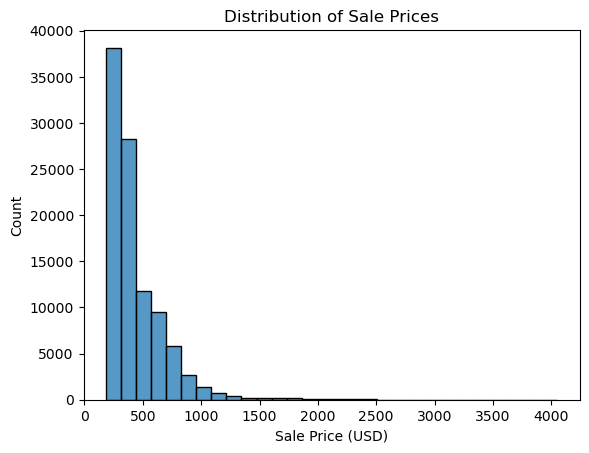

In [2]:
# First visualization
sns.histplot(data=df, x='Sale Price', bins=30)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Count')
plt.show()

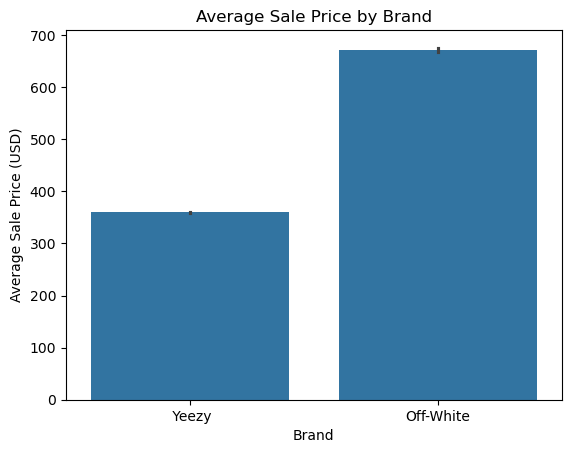

In [3]:
# Second visualization

sns.barplot(data=df, x='Brand', y='Sale Price')
plt.title('Average Sale Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Sale Price (USD)')
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.environ.get("API_KEY")
print(api_key[:5] + "...")

5d3a3...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [5]:
# Task a

import requests
import pandas as pd

url = "http://api.marketstack.com/v1/eod"

params = {
    "access_key": api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31"
}

response = requests.get(url, params=params)
data = response.json()

print("Status code:", response.status_code)
print("Data retrieved successfully")

# if you want to check the data, run the code below (not asked in task)
# display(data)

Status code: 200
Data retrieved successfully


In [6]:
# Task b

info = pd.DataFrame(data["data"])
info["date"] = pd.to_datetime(info["date"])

display(info.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


In [7]:
# Task c

ending_prices = info.pivot(index="date", columns="symbol", values="close")
display(ending_prices.describe())

returns = {}

for column in ending_prices:
    monthly_return = round(((ending_prices[column].iloc[-1] / ending_prices[column].iloc[0]) - 1) * 100, 2)
    returns[column] = monthly_return

returns_df = pd.DataFrame(list(returns.items()), columns=["symbol", "return_percentage"])
display(returns_df)


best_stock = max(returns, key=returns.get)
worst_stock = min(returns, key=returns.get)

print()
print("Best:",best_stock)
print("Worst:",worst_stock)

symbol,AAPL,AMZN,GOOG,META,NFLX
count,20.000000,20.000000,20.000000,20.000000,20.00000
mean,253.973500,210.138500,297.282500,611.058000,94.84450
std,4.843451,4.856686,11.232111,41.315247,2.51847
min,246.630000,199.340000,273.140000,525.720000,90.92000
25%,250.075000,207.637500,289.492500,593.475000,93.23250
50%,252.855000,210.005000,301.185000,614.695000,94.53000
75%,258.065000,213.280000,305.800000,645.492500,96.34750
max,262.520000,218.940000,309.410000,667.730000,99.17000


,symbol,return_percentage
0,AAPL,-3.33
1,AMZN,-3.94
2,GOOG,-5.47
3,META,-14.32
4,NFLX,-2.54



Best: NFLX
Worst: META


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

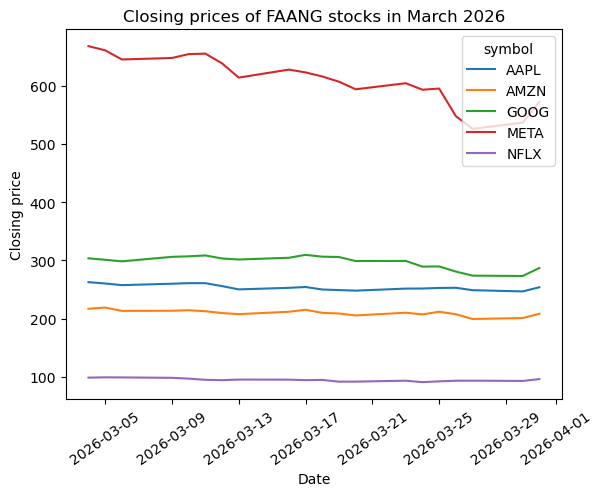

In [8]:
# Task a

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=info, x="date", y="close", hue="symbol")

plt.title("Closing prices of FAANG stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.xticks(rotation=35)
plt.show()

,symbol,return_percentage
0,AAPL,-3.33
1,AMZN,-3.94
2,GOOG,-5.47
3,META,-14.32
4,NFLX,-2.54


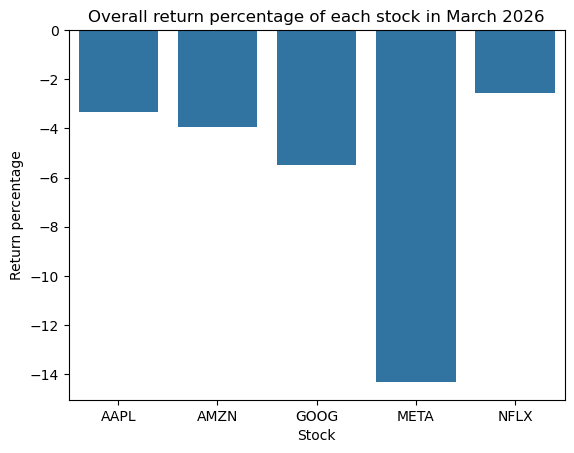

In [9]:
# Task b

returns_df = pd.DataFrame(list(returns.items()), columns=["symbol", "return_percentage"])
display(returns_df)

sns.barplot(data=returns_df, x="symbol", y="return_percentage")

plt.title("Overall return percentage of each stock in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return percentage")
plt.show()

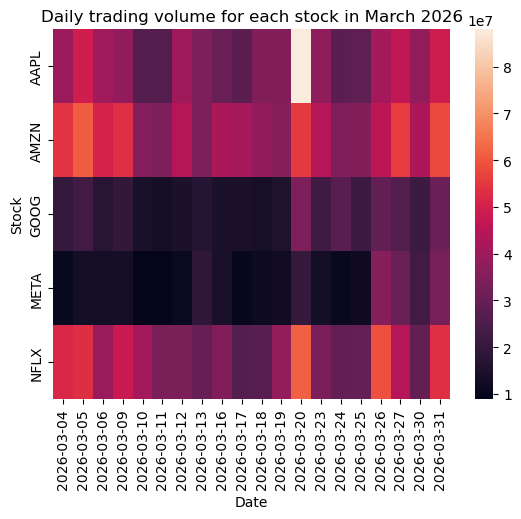

In [10]:
# Task c

info2 = info.copy()
info2 = info2.sort_values("date")
info2["date"] = pd.to_datetime(info2["date"]).dt.strftime("%Y-%m-%d")

volume_data = info2.pivot(index="symbol", columns="date", values="volume")


sns.heatmap(data=volume_data)

plt.title("Daily trading volume for each stock in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.show()

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [11]:
# Task a
import json

with open("exports/stockdata.json", "w") as file:
    json.dump(data, file) # "data" contains the original JSON response from the API in Task 2a

In [12]:
# Task b
info.to_csv("exports/stockdata.csv", index=False)

In [27]:
# Task c
with open("exports/stockdata.json", "r") as file:
    test1 = json.load(file)

test1 = pd.DataFrame(test1["data"])
display(test1.head(5))

test2 = pd.read_csv("exports/stockdata.csv")
display(test2.head(5))

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [14]:
import sqlite3

# Task a

connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type = 'table';")
tables = db.fetchall()
print(tables)

[('Categories',), ('sqlite_sequence',), ('CustomerCustomerDemo',), ('CustomerDemographics',), ('Customers',), ('Employees',), ('EmployeeTerritories',), ('Order Details',), ('Orders',), ('Products',), ('Regions',), ('Shippers',), ('Suppliers',), ('Territories',)]


In [15]:
# Task b

db.execute("SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30;")
retrieves = db.fetchall()
retrieves = pd.DataFrame(retrieves, columns = ["ProductName", "UnitPrice", "UnitsInStock"])
display(retrieves) #Task says print, but earlier in instruction it was noted to prefer using display() instead of print()



,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [16]:
# Task c

db.execute("""
SELECT
    c.CompanyName,
    o.OrderID,
    o.OrderDate,
    o.ShipCountry,
    od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c
    ON o.CustomerID = c.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
""")

germany_orders = db.fetchall()
germany_orders = pd.DataFrame(germany_orders, columns=["CompanyName", "OrderID", "OrderDate", "ShipCountry", "LineTotal"])

display(germany_orders)

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

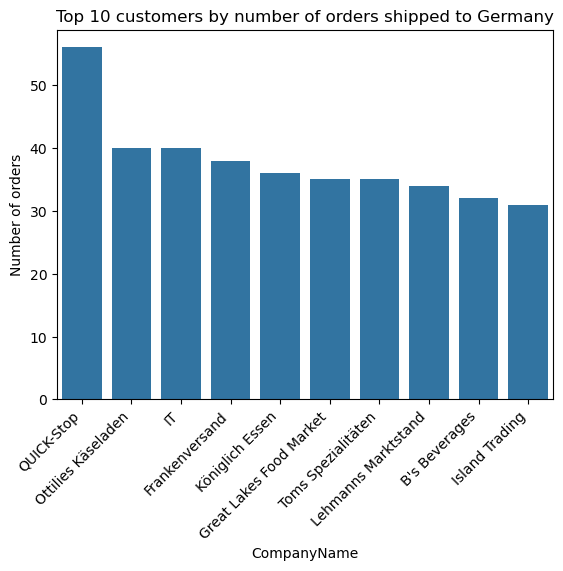

In [17]:
# Task a

top10 = germany_orders.groupby("CompanyName")["OrderID"].nunique().sort_values(ascending=False).head(10)
top10 = top10.reset_index(name="NumberOfOrders")

sns.barplot(data=top10, x="CompanyName", y="NumberOfOrders")
plt.xticks(rotation=45, ha='right')
plt.xlabel("CompanyName")
plt.ylabel("Number of orders")
plt.title("Top 10 customers by number of orders shipped to Germany")
plt.show()

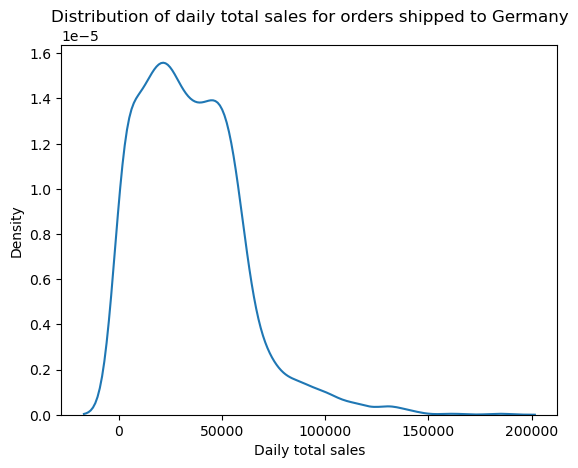

In [18]:
# Task b

daily_sales = germany_orders.copy()
daily_sales["OrderDate"] = pd.to_datetime(daily_sales["OrderDate"], format="mixed").dt.date
daily_sales = daily_sales.groupby("OrderDate")["LineTotal"].sum()

sns.kdeplot(data=daily_sales)
plt.xlabel("Daily total sales")
plt.ylabel("Density")
plt.title("Distribution of daily total sales for orders shipped to Germany")
plt.show()

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


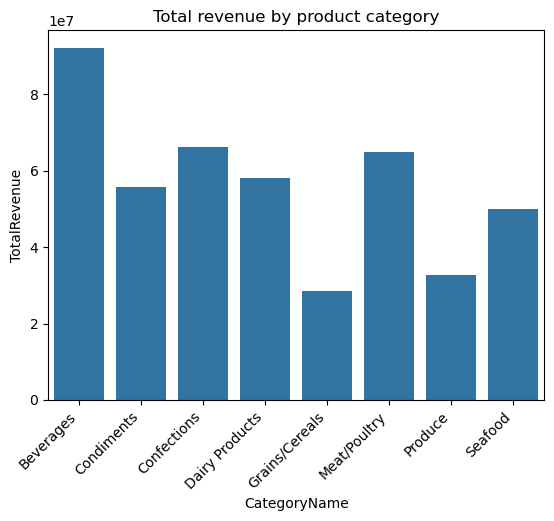

In [19]:
# Task c

db.execute("""
SELECT
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories c
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
""")

category_revenue = db.fetchall()
category_revenue = pd.DataFrame(category_revenue, columns=["CategoryName", "TotalRevenue"])
display(category_revenue)

sns.barplot(data=category_revenue, x="CategoryName", y="TotalRevenue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("CategoryName")
plt.ylabel("TotalRevenue")
plt.title("Total revenue by product category")
plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [20]:
# Task a

db.execute("SELECT * FROM Products;")
products_query = db.fetchall()
products_query = pd.DataFrame(products_query,  columns=[
    "ProductID",
    "ProductName",
    "SupplierID",
    "CategoryID",
    "QuantityPerUnit",
    "UnitPrice",
    "UnitsInStock",
    "UnitsOnOrder",
    "ReorderLevel",
    "Discontinued"
])
display(products_query.head(5))

db.execute("SELECT * FROM Categories;")
categories_query = db.fetchall()
categories_query = pd.DataFrame(categories_query, columns=[
    "CategoryID",
    "CategoryName",
    "Description",
    "Picture"
])
display(categories_query.head(5))


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [21]:
# Task b
merged = pd.merge(products_query, categories_query, how = "inner", on = "CategoryID")
display(merged)

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,Röd Kaviar,17,8,24 - 150 g jars,15.00,101,0,5,0,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
73,74,Longlife Tofu,4,7,5 kg pkg.,10.00,4,20,5,0,Produce,Dried fruit and bean curd,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
74,75,Rhönbräu Klosterbier,12,1,24 - 0.5 l bottles,7.75,125,0,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
75,76,Lakkalikööri,23,1,500 ml,18.00,57,0,20,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [22]:
#Task c

import time

start_sql = time.time()

db.execute("""
SELECT
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
""")

sql_result = pd.DataFrame(db.fetchall(), columns=["CategoryName", "TotalRevenue"])
sql_time = time.time() - start_sql

start_python = time.time()

db.execute('SELECT * FROM "Order Details";')
order_details = pd.DataFrame(db.fetchall(), columns=["OrderID", "ProductID", "UnitPrice", "Quantity", "Discount"])

db.execute("SELECT * FROM Products;")
products = pd.DataFrame(db.fetchall(), columns=["ProductID", "ProductName", "SupplierID", "CategoryID", "QuantityPerUnit", "UnitPrice", "UnitsInStock", "UnitsOnOrder", "ReorderLevel", "Discontinued"])

db.execute("SELECT * FROM Categories;")
categories = pd.DataFrame(db.fetchall(), columns=["CategoryID", "CategoryName", "Description", "Picture"])

merged = pd.merge(order_details, products, on="ProductID")
merged = pd.merge(merged, categories, on="CategoryID")
merged["LineTotal"] = merged["UnitPrice_x"] * merged["Quantity"]

python_result = merged.groupby("CategoryName")["LineTotal"].sum().reset_index()
python_time = time.time() - start_python

print("SQL execution time:", sql_time)
print("Python/pandas execution time:", python_time)

if sql_time < python_time:
    print("SQL was faster.")
else:
    print("Python was faster.")

SQL execution time: 0.1957719326019287
Python/pandas execution time: 0.5190870761871338
SQL was faster.


### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [23]:
# Task a

import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

display(wide_data) # Before

wide_to_long = wide_data.melt(id_vars = "store",
                      var_name = "Q",
                      value_name = "sales"
                      )

display(wide_to_long) # After

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Q,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [24]:
# Task b
display(long_data)

long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
)

display(long_to_wide.rename_axis(columns=None).reset_index())

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [26]:
# Task c

# wide -> long -> wide
wide_back = wide_to_long.pivot(
    index="store",
    columns="Q",
    values="sales"
)
display(wide_back.rename_axis(columns=None).reset_index())
display(wide_data)

# long -> wide -> long
long_back = long_to_wide.reset_index().melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)
display(long_back)
display(long_data)

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


AI use statement:

The tasks have been completed with as little AI assistance as possible. 
Claude was used as a coding companion in various degrees in harder tasks 
that did not have example code in the course materials, to help clarify 
problems, and to polish code structure before submission. AI was also 
used for help with chart labeling (like helping to pivot data on the x-axis).